# Dia 3 · Módulo 7 — De onde vieram os dados
### Estatística Básica Aplicada · Python

Nos dois primeiros dias tratamos os dados como se fossem a realidade. Descrevemos, relacionamos,
discutimos causa — sempre assumindo que a base que chegou até nós **representa** aquilo sobre o
que queremos falar.

Este módulo derruba essa suposição.

> ## Quem NÃO está nesta base de dados?
> ## E o que a ausência dessas pessoas fez com o meu número?

**O que a turma vai levar deste módulo:**
1. O erro mais caro da estatística **não** é de cálculo: é de **quem foi medido**.
2. **Viés do sobrevivente**: a amostra que sobrou é a que menos representa o problema.
3. **Não-resposta** não é ausência neutra — quem responde é diferente de quem não responde.
4. A lição mais contraintuitiva do curso: **amostra enorme e enviesada é pior que amostra
   pequena e honesta**.
5. Mais dados reduz **variância**, nunca **viés** — e é por isso que a origem importa mais que o `n`.

> ⚠️ Você não precisa escrever código do zero: **ler → prever → rodar → interpretar → modificar**.

## Roteiro e tempo

| Seção | Assunto | Ideia central |
|---|---|---|
| ⓪ | Os aviões que voltaram | a amostra que você vê é a que sobreviveu |
| ① | População × amostra | sobre quem você quer falar × quem você mediu |
| ② | Não-resposta | o silêncio não é neutro |
| ③ | Viés × variância | por que `n` grande não salva |
| ④ | O que mais dados resolve | e o que não resolve |
| ⑤ | Decisão: as perguntas sobre a origem | |

Se a turma levar **uma única** seção deste dia, que seja a ⓪ combinada com a ③.

In [1]:
# --- Preparação do ambiente ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

COR = {
    "media":     "#2a78d6",   # azul
    "dados":     "#9ec5f4",   # azul claro
    "verdade":   "#1baf7a",   # verde    — o valor real da população
    "alerta":    "#e34948",   # vermelho — o viés
    "amostra":   "#4a3aa7",   # violeta  — a estimativa
    "ausente":   "#d6d5cd",   # cinza    — quem ficou de fora
}

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.labelcolor": "#52514e", "xtick.color": "#898781", "ytick.color": "#898781",
    "font.size": 10, "lines.linewidth": 2, "figure.dpi": 110,
})

print("Ambiente pronto.")

Ambiente pronto.


---
# ⓪ Os aviões que voltaram

**Segunda Guerra Mundial.** A Marinha americana quer blindar os bombardeiros, mas blindagem pesa
— só dá para reforçar algumas áreas. Os oficiais examinam as aeronaves **que retornaram** das
missões e mapeiam onde estão os furos de bala.

O resultado é claro: a fuselagem e as asas estão crivadas; os motores, quase limpos. A
recomendação militar é imediata — **blindar onde estão os furos**.

O estatístico **Abraham Wald**, do Statistical Research Group, discorda e dá a resposta que
inverte tudo: **blinde exatamente onde NÃO há furos.**

**Antes de rodar:** por que Wald estava certo?

In [2]:
# --- Simulando 2.000 missões: os aviões atingidos no motor não voltam ---
rng = np.random.default_rng(4)
NA = 2000
regioes = ["motor", "fuselagem", "asas", "cauda"]

# o fogo antiaéreo atinge todas as regiões com a MESMA intensidade média
tiros = {r: rng.poisson(1.0, NA) for r in regioes}

# ...mas um tiro no motor é quase sempre fatal; nas outras regiões, quase nunca
letalidade = {"motor": 0.80, "fuselagem": 0.04, "asas": 0.06, "cauda": 0.03}

prob_voltar = np.ones(NA)
for r in regioes:
    prob_voltar *= (1 - letalidade[r]) ** tiros[r]
voltou = rng.random(NA) < prob_voltar

print(f"De {NA} aeronaves, {voltou.sum()} voltaram e {(~voltou).sum()} foram abatidas.\n")
print(f"{'região':<12} | {'furos/avião: TODOS':>19} | {'furos/avião: os que VOLTARAM':>29}")
print("-" * 68)
for r in regioes:
    print(f"{r:<12} | {tiros[r].mean():>19.2f} | {tiros[r][voltou].mean():>29.2f}")

print("\nColuna do meio (a realidade): o inimigo acerta TODAS as regiões por igual — 1,0 furo.")
print("Coluna da direita (o que se vê no pátio): o motor aparece quase limpo.")
print("\nO motor não é pouco atingido. É que o avião atingido no motor NÃO VOLTA para ser contado.")

De 2000 aeronaves, 749 voltaram e 1251 foram abatidas.

região       |  furos/avião: TODOS |  furos/avião: os que VOLTARAM
--------------------------------------------------------------------
motor        |                1.04 |                          0.21
fuselagem    |                0.98 |                          0.95
asas         |                1.01 |                          0.94
cauda        |                0.96 |                          0.88

Coluna do meio (a realidade): o inimigo acerta TODAS as regiões por igual — 1,0 furo.
Coluna da direita (o que se vê no pátio): o motor aparece quase limpo.

O motor não é pouco atingido. É que o avião atingido no motor NÃO VOLTA para ser contado.


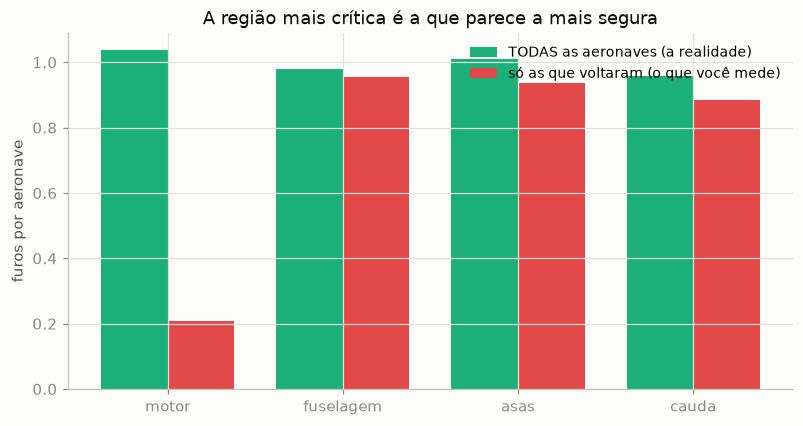

No motor, os dados observados subestimam os furos em 80%.

A lógica de Wald: se os aviões que voltaram têm poucos furos no motor, é porque
furo no motor derruba o avião. Blinde o motor.

Essa decisão salvou um número incontável de tripulações — e nasceu de perceber
QUEM ESTAVA FALTANDO na amostra.


In [3]:
# --- O mesmo fato, em gráfico ---
larg = 0.38
pos = np.arange(len(regioes))
media_todos = [tiros[r].mean() for r in regioes]
media_volta = [tiros[r][voltou].mean() for r in regioes]

plt.figure(figsize=(8.5, 4.2))
plt.bar(pos - larg/2, media_todos, larg, color=COR["verdade"],
        label="TODAS as aeronaves (a realidade)")
plt.bar(pos + larg/2, media_volta, larg, color=COR["alerta"],
        label="só as que voltaram (o que você mede)")
plt.xticks(pos, regioes)
plt.ylabel("furos por aeronave")
plt.title("A região mais crítica é a que parece a mais segura", color="#0b0b0b")
plt.legend(frameon=False, fontsize=9)
plt.show()

falta = 1 - media_volta[0] / media_todos[0]
print(f"No motor, os dados observados subestimam os furos em {falta:.0%}.")
print("\nA lógica de Wald: se os aviões que voltaram têm poucos furos no motor, é porque")
print("furo no motor derruba o avião. Blinde o motor.")
print("\nEssa decisão salvou um número incontável de tripulações — e nasceu de perceber")
print("QUEM ESTAVA FALTANDO na amostra.")

> ### 🔑 A ideia central do módulo
> **A sua amostra é o resultado de um processo — e esse processo pode ser parte do fenômeno que
> você quer estudar.**
>
> Nenhuma estatística calculada sobre os aviões que voltaram denuncia o problema: a média está
> certa, o desvio padrão está certo, o gráfico está certo. Tudo está correto **para a população
> errada**.
>
> Isso é o mesmo mecanismo do **colisor** (Módulo 6, §④), agora na sua forma mais famosa. E ele
> tem um nome próprio: **viés do sobrevivente**.

**Onde ele aparece na sua rotina:**

| Você analisa... | Quem está faltando | A conclusão errada que aparece |
|---|---|---|
| viaturas que voltaram da operação | as que ficaram no caminho | "o motor é a parte mais confiável" |
| militares que concluíram o curso | os que desistiram | "o curso é pouco exigente" |
| empresas que existem hoje | as que faliram | "essa estratégia dá certo" |
| projetos entregues | os cancelados | "nosso método nunca falha" |
| equipamentos que chegaram à revisão | os que foram descartados antes | "esse componente dura muito" |

---
# ① População × amostra

Dois conceitos que parecem burocráticos e decidem tudo:

- **População (ou população-alvo):** o conjunto sobre o qual você quer **afirmar** algo. "Todos
  os militares da Brigada."
- **Amostra:** quem de fato **entrou** na sua conta. "Os 120 que responderam ao formulário."

O trabalho inteiro da estatística é atravessar essa ponte. E ela só se sustenta sob uma
condição: a amostra precisa ser **representativa** — nenhum tipo de militar pode ter mais
chance de entrar nela por um motivo ligado ao que se está medindo.

**A amostra aleatória simples** (sortear quem entra) garante isso, exatamente pelo mesmo motivo
que o sorteio funcionou no Módulo 6, §⑤: nenhuma característica, medida ou não, consegue se
concentrar sistematicamente na amostra.

In [4]:
# --- A brigada inteira (que na vida real você NUNCA vê por completo) ---
rng1 = np.random.default_rng(19)
NB = 5000

# a população-alvo: toda a brigada
op_especiais = rng1.random(NB) < 0.15                                  # 15% são de op. especiais
tempo_pop = np.where(op_especiais,
                     rng1.normal(9.4, 0.7, NB),                        # mais rápidos
                     rng1.normal(11.3, 1.0, NB))                       # os demais

VERDADE = tempo_pop.mean()
print(f"VERDADE da brigada (que ninguém conhece): {VERDADE:.3f} min\n")

# --- três formas de montar uma amostra de 200 militares ---
print(f"{'como a amostra foi montada':<40} | {'estimativa':>11} | {'erro':>7}")
print("-" * 66)

# 1) sorteio honesto
idx = rng1.choice(NB, 200, replace=False)
est1 = tempo_pop[idx].mean()
print(f"{'sorteio aleatório de 200':<40} | {est1:>11.3f} | {est1 - VERDADE:>+7.3f}")

# 2) 'quem estava no pátio na hora' — os de op. especiais treinam de manhã e estavam lá
peso = np.where(op_especiais, 5.0, 1.0)
idx2 = rng1.choice(NB, 200, replace=False, p=peso / peso.sum())
est2 = tempo_pop[idx2].mean()
print(f"{'quem estava no pátio (voluntários)':<40} | {est2:>11.3f} | {est2 - VERDADE:>+7.3f}")

# 3) 'os 200 primeiros da lista de aptos' — exclui quem estava em recuperação
aptos = tempo_pop < np.percentile(tempo_pop, 80)
idx3 = rng1.choice(np.where(aptos)[0], 200, replace=False)
est3 = tempo_pop[idx3].mean()
print(f"{'só os aptos (exclui recuperação)':<40} | {est3:>11.3f} | {est3 - VERDADE:>+7.3f}")

print("\nAs três amostras têm EXATAMENTE o mesmo tamanho: 200 militares.")
print("Só a primeira responde à pergunta que o comando fez.")

VERDADE da brigada (que ninguém conhece): 10.988 min

como a amostra foi montada               |  estimativa |    erro
------------------------------------------------------------------
sorteio aleatório de 200                 |      10.960 |  -0.028
quem estava no pátio (voluntários)       |      10.234 |  -0.754
só os aptos (exclui recuperação)         |      10.704 |  -0.284

As três amostras têm EXATAMENTE o mesmo tamanho: 200 militares.
Só a primeira responde à pergunta que o comando fez.


---
# ② Não-resposta: o silêncio não é neutro

O caso mais frequente na prática administrativa. Você manda o formulário para toda a OM, e uma
parte responde. É tentador tratar os que não responderam como "ausentes por acaso".

Quase nunca é o caso: **a disposição de responder costuma estar ligada justamente ao que você
está perguntando.**

**Antes de rodar:** numa pesquisa de satisfação com o rancho, quem tem mais motivação para
responder — o militar satisfeito ou o insatisfeito?

satisfação VERDADEIRA da OM      : 6.82
satisfação MEDIDA (quem respondeu): 5.64
taxa de resposta                  : 14.8%
viés                              : -1.17 pontos



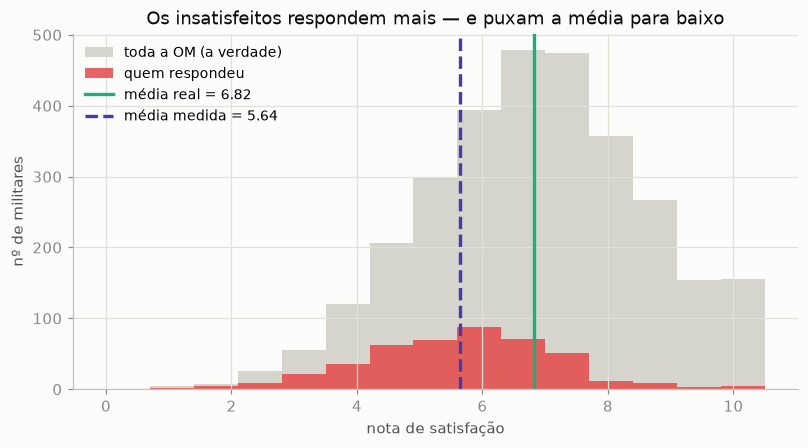

O relatório vai dizer que a OM está insatisfeita. A OM não está — os SATISFEITOS
é que não se deram ao trabalho de responder.

Repare que NADA no formulário denuncia isso. Os que faltam não deixam rastro.


In [5]:
# --- Pesquisa de satisfação com o rancho: 3.000 militares ---
rng2 = np.random.default_rng(27)
NR = 3000

satisfacao = np.clip(rng2.normal(6.8, 1.8, NR), 0, 10)      # nota real de 0 a 10
VERDADE_SAT = satisfacao.mean()

# quanto MAIS insatisfeito, maior a vontade de responder (quem está bem não se dá ao trabalho)
p_responder = np.clip(0.60 - 0.07 * satisfacao, 0.03, 0.90)
respondeu = rng2.random(NR) < p_responder

print(f"satisfação VERDADEIRA da OM      : {VERDADE_SAT:.2f}")
print(f"satisfação MEDIDA (quem respondeu): {satisfacao[respondeu].mean():.2f}")
print(f"taxa de resposta                  : {respondeu.mean():.1%}")
print(f"viés                              : {satisfacao[respondeu].mean() - VERDADE_SAT:+.2f} pontos\n")

plt.figure(figsize=(8.5, 4.2))
faixas = np.arange(0, 10.6, 0.7)
plt.hist(satisfacao, bins=faixas, color=COR["ausente"], label="toda a OM (a verdade)")
plt.hist(satisfacao[respondeu], bins=faixas, color=COR["alerta"], alpha=0.85,
         label="quem respondeu")
plt.axvline(VERDADE_SAT, color=COR["verdade"], linewidth=2.2, label=f"média real = {VERDADE_SAT:.2f}")
plt.axvline(satisfacao[respondeu].mean(), color=COR["amostra"], linewidth=2.2,
            linestyle="--", label=f"média medida = {satisfacao[respondeu].mean():.2f}")
plt.title("Os insatisfeitos respondem mais — e puxam a média para baixo", color="#0b0b0b")
plt.xlabel("nota de satisfação"); plt.ylabel("nº de militares")
plt.legend(frameon=False, fontsize=9)
plt.show()

print("O relatório vai dizer que a OM está insatisfeita. A OM não está — os SATISFEITOS")
print("é que não se deram ao trabalho de responder.")
print("\nRepare que NADA no formulário denuncia isso. Os que faltam não deixam rastro.")

> **O número que quase ninguém reporta e que muda tudo: a taxa de resposta.**
>
> Uma pesquisa com 15% de resposta não é "uma pesquisa com poucos dados". É uma pesquisa em que
> **85% da população decidiu, por conta própria, se entraria ou não** — e essa decisão foi
> tomada com base no que ela pensava sobre o assunto.
>
> Ao ler um artigo ou relatório baseado em questionário, procure primeiro por três coisas:
> **quantos foram convidados, quantos responderam, e o que se sabe sobre os que não responderam.**
> Se não estiver lá, o resultado não é interpretável — não importa quantas casas decimais tenha.

---
# ③ Viés × variância: por que `n` grande não salva

Chegamos à lição mais contraintuitiva do curso, e a mais importante para ler qualquer coisa em
2026 — inclusive resultados de IA.

Existem **dois** tipos de erro em uma estimativa, e eles se comportam de formas opostas:

| | O que é | O que acontece quando `n` cresce |
|---|---|---|
| **Variância** | o quanto a estimativa **balança** de amostra para amostra | **cai** com √n (Módulo 2, §⑤) |
| **Viés** | o quanto ela erra **sistematicamente**, sempre para o mesmo lado | **não muda** |

Mais dados encolhem o balanço em torno do alvo. Se o alvo estiver no lugar errado, mais dados só
te levam com mais precisão ao lugar errado.

**Antes de rodar:** um levantamento enviesado com 50.000 militares é melhor ou pior que um
sorteio honesto com 200?

In [6]:
# --- Sorteio honesto (n pequeno) × levantamento enviesado (n gigante) ---
rng3 = np.random.default_rng(33)
REPS = 400

peso = np.where(op_especiais, 5.0, 1.0)      # o defeito da coleta: op. especiais aparecem 5x mais
peso = peso / peso.sum()

def amostra_honesta(n):
    return tempo_pop[rng3.choice(NB, n, replace=True)].mean()

def amostra_enviesada(n):
    # sempre o MESMO defeito, independentemente de quantos militares você medir
    return tempo_pop[rng3.choice(NB, n, replace=True, p=peso)].mean()

print(f"VERDADE da brigada: {VERDADE:.3f} min\n")
print(f"{'n':>6} | {'HONESTA: erro típico':>21} | {'ENVIESADA: erro típico':>23}")
print("-" * 56)
for n in [50, 200, 800, 3200]:
    e_h = np.array([amostra_honesta(n) - VERDADE for _ in range(REPS)])
    e_v = np.array([amostra_enviesada(n) - VERDADE for _ in range(REPS)])
    print(f"{n:>6} | {np.sqrt((e_h**2).mean()):>21.3f} | {np.sqrt((e_v**2).mean()):>23.3f}")

print("\nColuna do meio: o erro CAI conforme n cresce — é o √n de sempre.")
print("Coluna da direita: o erro ESTACIONA. Ele não é falta de dados, é viés.")
print("\nCom n = 50 honestos você já erra MENOS que com n = 3.200 enviesados.")
print("E, pior: quanto maior o n enviesado, mais CONFIANTE você fica no número errado.")

VERDADE da brigada: 10.988 min

     n |  HONESTA: erro típico |  ENVIESADA: erro típico
--------------------------------------------------------


    50 |                 0.162 |                   0.639
   200 |                 0.087 |                   0.623
   800 |                 0.044 |                   0.617


  3200 |                 0.020 |                   0.618

Coluna do meio: o erro CAI conforme n cresce — é o √n de sempre.
Coluna da direita: o erro ESTACIONA. Ele não é falta de dados, é viés.

Com n = 50 honestos você já erra MENOS que com n = 3.200 enviesados.
E, pior: quanto maior o n enviesado, mais CONFIANTE você fica no número errado.


### O caso histórico: 2,4 milhões de respostas erradas

**Eleição americana de 1936.** A revista *Literary Digest* fez a maior pesquisa eleitoral da
história até então: enviou 10 milhões de questionários e recebeu **2,4 milhões de respostas**.
Previu vitória folgada de Landon.

George Gallup, com cerca de **50 mil** entrevistas, previu vitória de Roosevelt. Roosevelt venceu
com 61% dos votos — uma das maiores vitórias da história americana. A *Literary Digest* faliu
pouco depois.

O que deu errado: as listas de endereços vinham de registros de **automóveis e telefones** —
em plena Grande Depressão, isso significava entrevistar os mais ricos. E, sobre isso, a
**não-resposta** (§②) adicionou o resto do estrago.

> **2,4 milhões de respostas não corrigiram um erro que 50 mil bem escolhidas evitaram.** O
> tamanho da amostra combateu a variância — e a variância não era o problema.
>
> Esse fenômeno tem nome moderno: **o paradoxo do "big data"**. Quanto maior a base, menor o
> intervalo de confiança e **maior a certeza no número errado**, se a coleta for enviesada.
> Guarde esta frase para o Módulo 9: bases gigantescas de treino de IA são coletadas
> exatamente assim — por conveniência, não por sorteio.

---
# ④ O que mais dados resolve — e o que não resolve

Vale organizar, porque "coletar mais dados" é a resposta automática para quase todo problema — e
ela só funciona para uma parte deles.

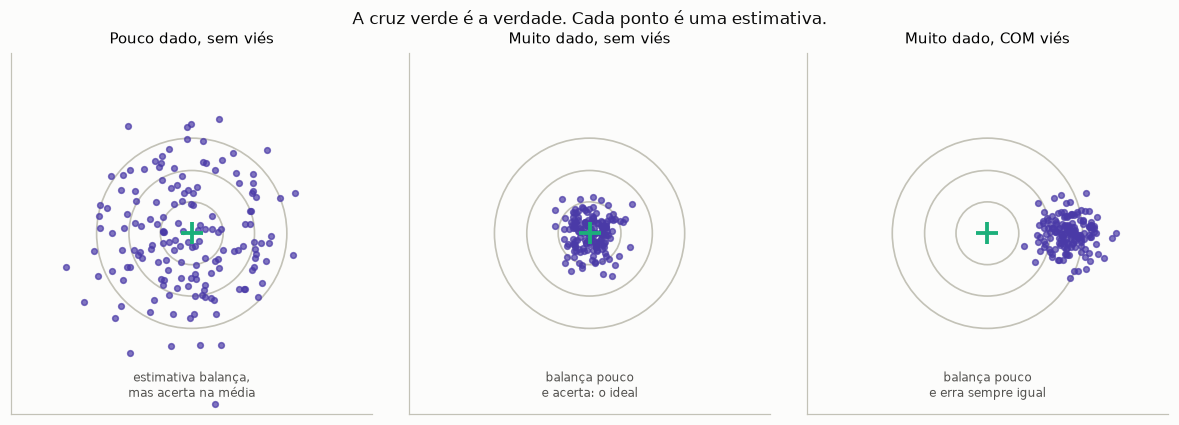

Do 1º para o 2º painel: mais dados. O problema era variância, e foi resolvido.
Do 2º para o 3º painel: mesma quantidade de dados, coleta torta.
Nenhuma quantidade de dados move a nuvem do 3º painel de volta para o centro.


In [7]:
# --- O mesmo alvo, os dois erros, lado a lado ---
rng4 = np.random.default_rng(41)

fig, eixos = plt.subplots(1, 3, figsize=(11, 3.9))
cenarios = [
    ("Pouco dado, sem viés",   0.55, 0.00, "estimativa balança,\nmas acerta na média"),
    ("Muito dado, sem viés",   0.16, 0.00, "balança pouco\ne acerta: o ideal"),
    ("Muito dado, COM viés",   0.16, 0.85, "balança pouco\ne erra sempre igual"),
]
for eixo, (titulo, esp, vies, nota) in zip(eixos, cenarios):
    pontos_x = rng4.normal(vies, esp, 160)
    pontos_y = rng4.normal(0, esp, 160)
    for raio in [1.0, 0.66, 0.33]:
        eixo.add_patch(plt.Circle((0, 0), raio, fill=False, color="#c3c2b7", linewidth=1.1))
    eixo.scatter(pontos_x, pontos_y, s=14, color=COR["amostra"], alpha=0.7)
    eixo.scatter([0], [0], marker="+", s=200, color=COR["verdade"], linewidth=2.5)
    eixo.set_title(titulo, fontsize=10)
    eixo.set_xlim(-1.9, 1.9); eixo.set_ylim(-1.9, 1.9)
    eixo.set_aspect("equal"); eixo.set_xticks([]); eixo.set_yticks([])
    eixo.grid(False)
    eixo.annotate(nota, xy=(0, -1.72), ha="center", fontsize=8, color="#52514e")

fig.suptitle("A cruz verde é a verdade. Cada ponto é uma estimativa.", fontsize=11, color="#0b0b0b")
plt.tight_layout()
plt.show()

print("Do 1º para o 2º painel: mais dados. O problema era variância, e foi resolvido.")
print("Do 2º para o 3º painel: mesma quantidade de dados, coleta torta.")
print("Nenhuma quantidade de dados move a nuvem do 3º painel de volta para o centro.")

| Problema | Mais dados resolve? | O que resolve |
|---|---|---|
| a estimativa balança muito | ✅ **sim** | mais `n` (Módulo 2, §⑤) |
| `r` que apareceu por acaso | ✅ **sim** | mais `n` (Módulo 4, §4.2) |
| amostra só com voluntários | ❌ **não** | mudar o **processo de coleta** |
| não-resposta seletiva | ❌ **não** | perseguir os não respondentes |
| viés do sobrevivente | ❌ **não** | ir atrás de quem **não** voltou |
| confundidor não medido | ❌ **não** | sorteio (Módulo 6, §⑤) |

> ### ⚠️ E há uma armadilha extra
> O viés não apenas sobrevive ao aumento de `n` — ele fica **mais convincente**. Com `n` grande,
> o intervalo de confiança encolhe e o resultado ganha aparência de precisão científica.
>
> Você verá no **Módulo 8** que os intervalos de confiança medem **apenas a variância**. Eles
> não sabem nada sobre viés e não têm como avisar. Um intervalo estreitíssimo em torno do
> número errado é o produto típico de uma base grande e torta.

---
# ⑤ Decisão: as perguntas sobre a origem dos dados

Antes de qualquer cálculo — e antes de acreditar em qualquer relatório ou artigo — são estas as
perguntas:

| Pergunta | O que ela detecta |
|---|---|
| **Sobre quem eu quero afirmar algo?** (população-alvo) | a ponte que precisa ser atravessada |
| **Como cada registro entrou na base?** | seleção por conveniência, voluntariado |
| **Quem tinha chance de entrar e não entrou?** | viés do sobrevivente (§⓪) |
| **Quantos foram convidados e quantos responderam?** | não-resposta (§②) |
| **O filtro de entrada tem relação com o que estou medindo?** | colisor (Módulo 6, §④) |
| **Este número seria diferente se eu tivesse sorteado?** | o teste final |

### Três frases para levar

1. **Pergunte quem está faltando** — antes de olhar qualquer média.
2. **Amostra grande e torta é pior que amostra pequena e honesta**, porque dá confiança no erro.
3. **Mais dados resolvem variância, nunca viés.** São dois erros diferentes; só um deles cede a `n`.

---
# ⑥ Exercícios

**Exercício 1 — Quem está faltando?**

Para cada base, identifique a população-alvo, quem está ausente e para que lado o número erra:

1. Tempo médio de reparo, calculado sobre as **ordens de serviço encerradas** no mês.
2. Satisfação com o novo fardamento, medida entre os militares que **compareceram** à formatura.
3. Eficácia de um curso, medida pela nota dos **formandos**.
4. Confiabilidade de um rádio, medida nos aparelhos **enviados para revisão**.
5. Desempenho de uma nova ração operacional, medido em quem **terminou** o exercício de campo.

**Exercício 2 — Mude um parâmetro.**

Na célula da §③, acrescente `12800` à lista de valores de `n`. Antes de rodar, preveja: a coluna
"ENVIESADA" vai continuar estacionada no mesmo valor, vai cair um pouco, ou vai subir? Rode e
explique o que viu.

**Exercício 3 — Conserte o erro (conceitual, não de sintaxe).**

Um relatório afirma:

> "Aplicamos o questionário a toda a Brigada (efetivo 4.200). Obtivemos 380 respostas — uma
> amostra grande, de mais de 9% do efetivo. A margem de erro é de apenas ±2,5%, o que confere
> **alta precisão** ao resultado: 71% aprovam a nova escala de serviço."

Há **dois** erros conceituais graves. Encontre os dois. *(Dica: a margem de erro está medindo o
quê, exatamente?)*

**Exercício 4 — Desenhe a coleta (discussão em grupo).**

O comando quer estimar quantas horas por semana os militares da Brigada realmente dedicam a
treinamento físico fora do expediente.

1. Qual é a população-alvo, com precisão?
2. Cite **três** formas de coleta convenientes que produziriam viés, e diga a **direção** do erro
   de cada uma.
3. Descreva uma coleta que você defenderia perante o comando.
4. Se a taxa de resposta ficar em 40%, o que você faria **antes** de reportar o número?

---
## Resumo do módulo

| Conceito | O que é | Cuidado |
|---|---|---|
| **População-alvo** | sobre quem se quer afirmar | precisa ser declarada, não presumida |
| **Amostra representativa** | todo mundo com chance conhecida de entrar | conveniência ≠ representatividade |
| **Viés do sobrevivente** | só se vê quem "voltou" | o dado ausente não deixa rastro |
| **Não-resposta** | quem responde difere de quem não responde | reporte a **taxa de resposta** |
| **Viés** | erro sistemático, sempre para o mesmo lado | **não** cede a `n` |
| **Variância** | o balanço da estimativa | cede a `n`, com √n |

- **O erro mais caro não é de cálculo, é de coleta** — e nenhuma fórmula o detecta.
- **Grande e torta perde para pequena e honesta.** O tamanho combate a variância, não o viés.
- **Pergunte sempre quem está faltando.** Foi essa pergunta que blindou os motores em 1943.

➡️ **Próximo módulo:** agora que você sabe desconfiar da **origem** dos dados, falta desconfiar
do **tamanho** da diferença. Duas médias nunca saem exatamente iguais — nem quando não há
diferença nenhuma. Como separar o efeito real do balanço do acaso? É o intervalo de confiança, o
p-valor, e a diferença entre ser **estatisticamente significativo** e **importar na prática**.